### load data

In [25]:
import pandas as pd

data = pd.read_csv("F:/project/college project/code/data/procesed data/featured_stock_data.csv")

print(data.head())

        Open       High        Low      Close     Volume     Target  \
0  43.860911  43.908615  43.541316  43.820366   94318000  44.390385   
1  44.087487  44.678976  43.822747  44.390385  156171600  44.843540   
2  44.314061  44.931786  44.311673  44.843540  104879200  44.488182   
3  44.922261  45.074904  44.342694  44.488182  126585600  44.876945   
4  44.416631  45.194156  44.058874  44.876945  124140800  46.529770   

       MA_10      MA_50    Return  Volatility  
0  42.251723  39.373998  0.011117    0.012557  
1  42.517656  39.511731  0.013008    0.012680  
2  42.807914  39.733241  0.010208    0.012730  
3  43.070270  39.918812 -0.007924    0.013321  
4  43.395590  40.113726  0.008739    0.012650  


#  define x and y

In [ ]:
X = data[['Open', 'High', 'Low','Close','Volume', 'MA_10', 'MA_50', 'Return', 'Volatility']]
y = data['Target']
print(X.shape)
print(y.shape)

(1793, 8)
(1793,)


# train and split data

In [27]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# model(linear regression)

## train model

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## predict

In [29]:
y_pred = model.predict(X_test)

## evalution

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.0960789841663683
MSE: 19.508864624346593
RMSE: 4.416884040174317
R2 Score: 0.9708804304401998


### graph


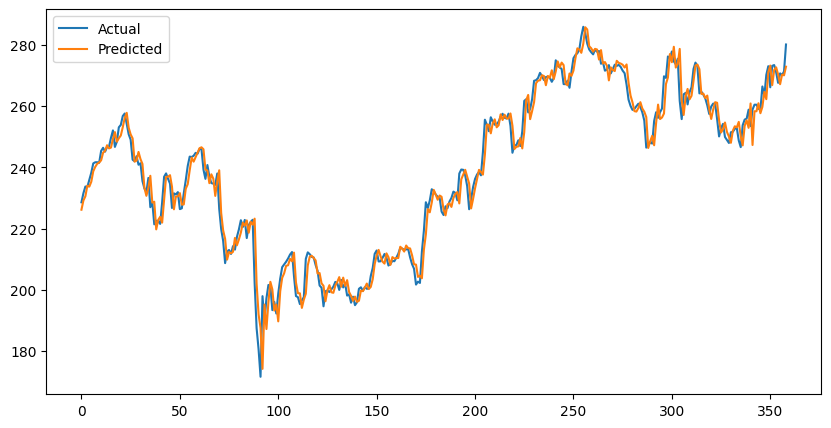

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

## compare model with baseline

In [ ]:
import numpy as np
baseline = X_test['Close']

from sklearn.metrics import mean_absolute_error
print("Baseline MAE:", mean_absolute_error(y_test, baseline))

Baseline MAE: 2.8306472905831077


### isights

Baseline MAE ≈ 2.83  
Model MAE ≈ 2.88
model MAE = 3.09 ( without close)
this very similiar so model  model actually learing tommorow is  today price 


# save model 

In [33]:
import joblib

joblib.dump(model, "../model_save/linear_regression.pkl")

['../model_save/linear_regression.pkl']